In [ ]:
# Cell 1: Mount Drive and basic setup (run first)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, json, numpy as np, pandas as pd
import tensorflow as tf
from pathlib import Path

# Update these if you used different names
DRIVE_ROOT = "/content/drive/MyDrive"
DATA_ROOT = os.path.join(DRIVE_ROOT, "newDataset")
PREPRO_ROOT = os.path.join(DATA_ROOT, "preprocessed")
MODEL_DIR = os.path.join(DATA_ROOT, "Model")

# Basic training params you used earlier (ensure they match)
IMG_SIZE = (380, 380)   # must match preprocessing
BATCH_SIZE = 20

print("DATA_ROOT:", DATA_ROOT)
print("PREPRO_ROOT:", PREPRO_ROOT)
print("MODEL_DIR:", MODEL_DIR)

# Path to your uploaded research paper (for reference)
print("Research paper (local path):", "/mnt/data/researchPaper_faizal.pdf")


Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/newDataset
PREPRO_ROOT: /content/drive/MyDrive/newDataset/preprocessed
MODEL_DIR: /content/drive/MyDrive/newDataset/Model
Research paper (local path): /mnt/data/researchPaper_faizal.pdf


In [ ]:
# Cell 2: Recreate test generator, load best model, predict on test set and save CSV
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import os, numpy as np, pandas as pd

test_dir = os.path.join(PREPRO_ROOT, "test")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"Test preprocessed folder not found: {test_dir}. Make sure preprocessing was done and files exist.")

test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet.preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load best saved model - update file name if different
checkpoint_path = os.path.join(MODEL_DIR, "efficientnetb4_best.keras")
if not os.path.exists(checkpoint_path):
    # try alternative h5 extension if present
    alt = os.path.join(MODEL_DIR, "efficientnetb4_best.h5")
    if os.path.exists(alt):
        checkpoint_path = alt

print("Loading model from:", checkpoint_path)
model = load_model(checkpoint_path)
print("Model loaded.")

# Predict
test_steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
probs = model.predict(test_generator, steps=test_steps, verbose=1)
preds = np.argmax(probs, axis=1)
true = test_generator.classes
filenames = test_generator.filenames

# map indices to class names
class_indices = test_generator.class_indices
inv_class_indices = {v:k for k,v in class_indices.items()}

# Build results dataframe and save
cols = ["filename", "true_label", "pred_label"] + [f"prob_{i}" for i in range(probs.shape[1])]
rows = []
for i, fname in enumerate(filenames):
    rows.append([fname, inv_class_indices[true[i]], inv_class_indices[preds[i]]] + [float(probs[i,j]) for j in range(probs.shape[1])])
results_df = pd.DataFrame(rows, columns=cols)
results_csv = os.path.join(MODEL_DIR, "test_predictions.csv")
results_df.to_csv(results_csv, index=False)
print("Saved predictions to:", results_csv)


Found 1311 images belonging to 4 classes.
Loading model from: /content/drive/MyDrive/newDataset/Model/efficientnetb4_best.keras
Model loaded.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


66/66 ━━━━━━━━━━━━━━━━━━━━ 718s 11s/step
Saved predictions to: /content/drive/MyDrive/newDataset/Model/test_predictions.csv


=== IMAGE-LEVEL METRICS ===
Accuracy: 0.9817
Precision (macro): 0.9810
Recall (macro): 0.9803
F1-score (macro): 0.9805
Specificity (glioma): 0.9980
Specificity (meningioma): 0.9851
Specificity (notumor): 0.9978
Specificity (pituitary): 0.9951
AUC per class: {'glioma': 0.9993175074183976, 'meningioma': 0.9981367671446688, 'notumor': 0.9999645708990816, 'pituitary': 0.999891196834817}
Macro AUC: 0.9993275105742412
Saved metrics summary to /content/drive/MyDrive/newDataset/Model/metrics_summary.json


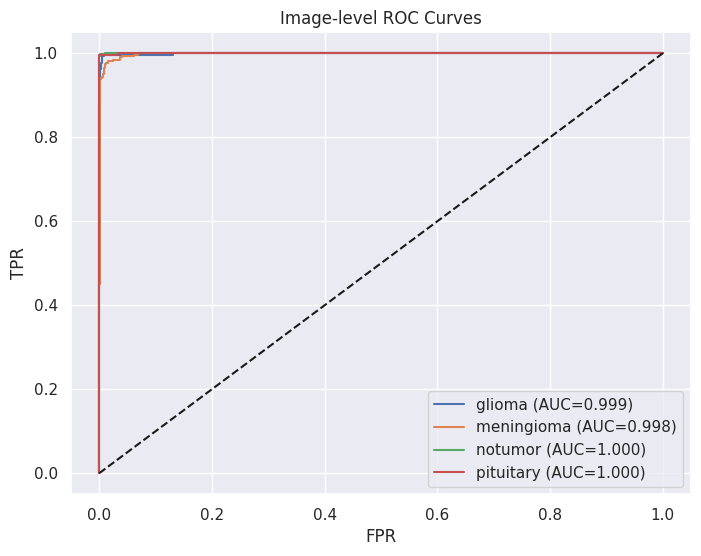

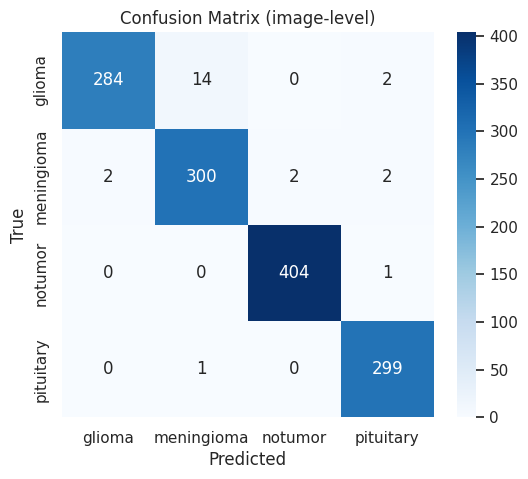

In [ ]:
# Cell 3: Compute metrics (Accuracy, Precision, Recall, F1, Specificity, AUC) and plot ROC/confusion matrix
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import json, os

sns.set()

y_true = np.array(true)
y_pred = np.array(preds)
NUM_CLASSES = probs.shape[1]

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_true, y_pred)

# Specificity per class
specificities = []
for i in range(NUM_CLASSES):
    TP = cm[i,i]; FP = cm[:,i].sum() - TP; FN = cm[i,:].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    specificities.append(spec)

# AUC per class (one-vs-rest)
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
fpr = {}; tpr = {}; roc_auc = {}
for i in range(NUM_CLASSES):
    try:
        fpr[i], tpr[i], _ = roc_curve(y_bin[:,i], probs[:,i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    except Exception:
        fpr[i], tpr[i], roc_auc[i] = [0],[0],0.0
macro_auc = np.mean([roc_auc[i] for i in range(NUM_CLASSES)])

print("=== IMAGE-LEVEL METRICS ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-score (macro): {f1:.4f}")
for i, spec in enumerate(specificities):
    print(f"Specificity ({inv_class_indices[i]}): {spec:.4f}")
print("AUC per class:", {inv_class_indices[i]: float(roc_auc[i]) for i in range(NUM_CLASSES)})
print("Macro AUC:", macro_auc)

# Save summary
summary = {
    "image_accuracy": float(acc),
    "image_precision_macro": float(prec),
    "image_recall_macro": float(rec),
    "image_f1_macro": float(f1),
    "image_macro_auc": float(macro_auc)
}
with open(os.path.join(MODEL_DIR, "metrics_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("Saved metrics summary to", os.path.join(MODEL_DIR, "metrics_summary.json"))

# Plot ROC curves
plt.figure(figsize=(8,6))
for i in range(NUM_CLASSES):
    if isinstance(fpr.get(i, None), (list, np.ndarray)):
        plt.plot(fpr[i], tpr[i], label=f"{inv_class_indices[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0,1],[0,1],'k--'); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Image-level ROC Curves"); plt.legend(); plt.show()

# Confusion matrix plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=[inv_class_indices[i] for i in range(NUM_CLASSES)],
            yticklabels=[inv_class_indices[i] for i in range(NUM_CLASSES)], cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (image-level)"); plt.show()


In [ ]:
model.save('efficientnetb4_best.h5')

TypeError: cannot pickle 'module' object